# Análise de Eficiência Energética em Sistema de Refrigeração Industrial

## Contexto

Sistemas de refrigeração industrial possuem papel estratégico na estabilidade térmica de processos produtivos e representam parcela significativa do consumo energético em plantas industriais.

A eficiência operacional desses sistemas pode ser avaliada por meio do **Coefficient of Performance (COP)**, indicador que relaciona a capacidade de remoção de calor com a potência elétrica consumida.

Este estudo realiza uma análise exploratória do desempenho de um sistema de refrigeração ao longo de uma semana de operação, com foco na identificação de padrões, regimes operacionais e eventos pontuais de degradação de eficiência.


In [1]:
import pandas as pd
import numpy as np

## Estrutura e Carregamento dos Dados

O conjunto de dados contém variáveis operacionais típicas de um sistema de refrigeração industrial, incluindo temperaturas, vazão, potência elétrica e parâmetros auxiliares.

Nesta etapa, os dados são carregados e inspecionados quanto à sua estrutura, tipos de variáveis e consistência inicial, garantindo base adequada para as etapas subsequentes de cálculo e análise.


In [2]:
df = pd.read_csv("dados_refrigeracao.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2016 entries, 0 to 2015
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         2016 non-null   object 
 1   temp_entrada_c    2016 non-null   float64
 2   temp_saida_c      2016 non-null   float64
 3   vazao_m3_h        2016 non-null   float64
 4   potencia_kw       2016 non-null   float64
 5   pressao_oleo_bar  2016 non-null   float64
 6   nivel_tanque_pct  2016 non-null   float64
dtypes: float64(6), object(1)
memory usage: 110.4+ KB


## Dicionário de Variáveis

As variáveis utilizadas representam medições típicas de um sistema de refrigeração industrial:

- **temp_entrada_c**  
  Temperatura da água na entrada do sistema (°C).

- **temp_saida_c**  
  Temperatura da água após o processo de resfriamento (°C).

- **vazao_m3_s**  
  Vazão volumétrica de água circulante no sistema (m³/s).

- **potencia_kw**  
  Potência elétrica total consumida pelo sistema (kW).

- **pressao_oleo_bar**  
  Pressão do óleo do compressor (bar).

- **nivel_tanque_pct**  
  Nível do tanque do sistema (%).

Essas variáveis permitem estimar a carga térmica removida e avaliar o desempenho energético por meio do COP.


## Tratamento e Consistência dos Dados

Antes do cálculo dos indicadores de desempenho, foi realizada uma etapa de verificação e preparação dos dados.

Essa etapa inclui:

- Conversão e validação do timestamp
- Tratamento de valores ausentes
- Verificação de inconsistências físicas (ex.: temperaturas invertidas ou potência negativa)
- Preparação das variáveis para cálculo da carga térmica

A qualidade dos dados é etapa essencial em análises industriais, pois medições incorretas podem levar a interpretações equivocadas do desempenho operacional.


### Tratamento do Tempo

A variável `timestamp` representa o instante de cada medição.  
Ela foi convertida para o formato datetime e utilizada como índice temporal, permitindo análises de séries temporais e identificação de padrões ao longo do período analisado.


In [3]:
TS_COL = "timestamp"

# Conversão para datetime
df[TS_COL] = pd.to_datetime(df[TS_COL], errors="coerce")

# Remove registros sem timestamp válido
df = df.dropna(subset=[TS_COL]).copy()

# Ordena cronologicamente
df = df.sort_values(TS_COL).copy()

# Remove timestamps duplicados (mantém o último valor)
df = df.drop_duplicates(subset=[TS_COL], keep="last").copy()

# Define índice temporal para o dataframe
df = df.set_index(TS_COL)

Outros parâmetros

In [4]:
num_cols = [
    "temp_entrada_c",
    "temp_saida_c",
    "vazao_m3_h",
    "potencia_kw",
    "pressao_oleo_bar",
    "nivel_tanque_pct"
]

for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Delta T (°C)
df["dT_C"] = df["temp_entrada_c"] - df["temp_saida_c"]

# Flags físicos de invalidez (vazão, potência, temperatura)
df["flag_vazao_invalida"]   = df["vazao_m3_h"] <= 0
df["flag_pot_invalida"]     = df["potencia_kw"] <= 0
df["flag_temp_invertida"]   = df["temp_entrada_c"] <= df["temp_saida_c"]
df["flag_dT_invalido"]      = df["dT_C"] <= 0  # redundante com temp_invertida, mas útil como resumo

# Consolidado de invalidez (pra filtro e auditoria)
df["flag_invalido"] = (
    df["flag_vazao_invalida"]
    | df["flag_pot_invalida"]
    | df["flag_dT_invalido"]
)

# Filtragem dos dados válidos
df_valid = df.loc[~df["flag_invalido"]].copy()

# Vazão em m³/s (assumindo que a tag está em m³/h)
df_valid["Vazao_m3_s"] = df_valid["vazao_m3_h"] / 3600.0

Relatório de arquivos enválidos:

In [5]:
total = len(df)
invalid = df["flag_invalido"].sum()
pct_invalid = invalid / total * 100

resumo_flags = pd.Series({
    "Total de linhas": total,
    "Linhas inválidas": invalid,
    "% inválidas": pct_invalid,
    "Vazão inválida": df["flag_vazao_invalida"].sum(),
    "Potência inválida": df["flag_pot_invalida"].sum(),
    "ΔT inválido": df["flag_dT_invalido"].sum(),
    "Temp invertida": df["flag_temp_invertida"].sum(),
})

resumo_flags


Total de linhas      2016.0
Linhas inválidas        0.0
% inválidas             0.0
Vazão inválida          0.0
Potência inválida       0.0
ΔT inválido             0.0
Temp invertida          0.0
dtype: float64

### Modelagem Física da Carga Térmica

A carga térmica removida pela água foi estimada a partir do balanço de energia:

$\dot{Q} = \dot{m} \cdot c_p \cdot \Delta T$

onde:

- $\dot{m}$ é a vazão mássica (kg/s),
- $c_p$ é o calor específico da água,
- $\Delta T$ é a diferença entre temperatura de entrada e saída.

Para os cálculos, foram considerados:

- Densidade da água: $ \rho = 1000 \, kg/m^3$
- Calor específico: $ c_p = 4180 \, J/(kg \cdot °C)$

A vazão volumétrica foi convertida de $ m^3/s $ para vazão mássica por meio da relação:

$\dot{m} = \rho \cdot \dot{V}$

Essa abordagem permite estimar a potência térmica removida e, consequentemente, calcular o Coefficient of Performance (COP) do sistema.


In [6]:
RHO = 1000.0 # kg/m3
CP = 4180.0 # J/kg.C

# Vazão mássica (kg/s)
df_valid["m_dot_kg_s"] = RHO * df_valid["Vazao_m3_s"]

# Carga térmica removida (W) e (kW)
df_valid["Qdot_W"]  = df_valid["m_dot_kg_s"] * CP * df_valid["dT_C"]
df_valid["Qdot_kW"] = df_valid["Qdot_W"] / 1000.0

# COP (adimensional)
df_valid["COP"] = df_valid["Qdot_kW"] / df_valid["potencia_kw"]

# Filtragem de COPs fisicamente plausíveis (0 < COP <= 20)
df_valid["flag_COP_invalido"] = (df_valid["COP"] <= 0) | (df_valid["COP"] > 20)
df_cop = df_valid.loc[~df_valid["flag_COP_invalido"]].copy()

## Análise Exploratória dos Dados

Nesta etapa foi realizada uma análise exploratória com o objetivo de compreender o comportamento operacional do sistema de refrigeração ao longo do período analisado.

A análise exploratória permite identificar:

- padrões operacionais predominantes,
- variabilidade de desempenho,
- possíveis eventos de degradação de eficiência,
- relações entre o COP e variáveis operacionais relevantes.

As visualizações apresentadas a seguir têm como foco principal o indicador de eficiência energética (COP) e sua interação com parâmetros como vazão, potência elétrica e diferença de temperatura.

Esse tipo de análise constitui uma etapa fundamental na interpretação de dados industriais, pois permite identificar rapidamente comportamentos anômalos ou regimes operacionais distintos antes da aplicação de modelos estatísticos ou preditivos mais avançados.

In [7]:
cop_stats = df_cop["COP"].describe(percentiles=[0.1, 0.25, 0.5, 0.75, 0.9])
cop_stats

count    2016.000000
mean        3.243186
std         0.500108
min         1.486778
10%         2.708801
25%         3.032839
50%         3.326981
75%         3.564948
90%         3.772873
max         4.274710
Name: COP, dtype: float64

A primeira avaliação do desempenho do sistema foi realizada por meio de estatísticas descritivas do COP, incluindo média, mediana e percentis.

Essas métricas permitem observar a distribuição do desempenho energético do sistema e identificar possíveis assimetrias ou presença de valores extremos.


### Evolução Temporal do COP

A análise temporal do COP permite observar a estabilidade operacional do sistema ao longo do período analisado.

Esse tipo de visualização é particularmente útil para identificar:

- variações de eficiência ao longo do tempo,
- eventos operacionais transitórios,
- possíveis regimes distintos de operação.

A linha tracejada representa o valor médio do COP no período analisado, servindo como referência para comparação do desempenho instantâneo do sistema.

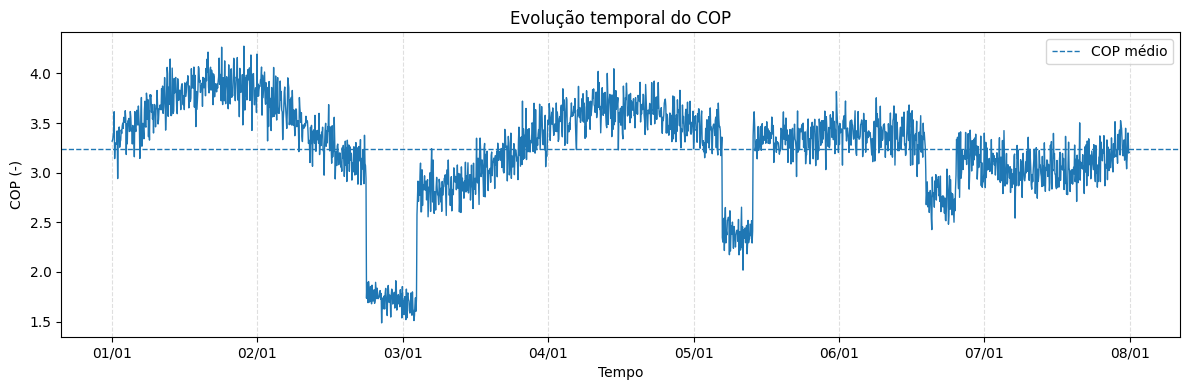

In [13]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

plt.figure(figsize=(12,4))

plt.plot(
    df_cop.index,
    df_cop["COP"],
    linewidth=1
)

plt.axhline(
    df_cop["COP"].mean(),
    linestyle="--",
    linewidth=1,
    label="COP médio"
)

plt.title("Evolução temporal do COP")
plt.ylabel("COP (-)")
plt.xlabel("Tempo")

ax = plt.gca()

ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))

ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.4)

plt.legend()

plt.tight_layout()
plt.show()


Observa-se que o sistema apresenta comportamento relativamente estável durante grande parte do período analisado, com valores de COP concentrados próximos à média.

Entretanto, alguns intervalos apresentam quedas abruptas no indicador, especialmente entre os dias 02/01 e 03/01, no início do dia 05/01 e próximo ao final do dia 06/01.

Esses eventos indicam momentos de degradação temporária da eficiência do sistema. A identificação dessas ocorrências é um passo importante da análise exploratória, pois permite direcionar investigações posteriores para compreender sua relação com variáveis operacionais como vazão, potência elétrica e diferença de temperatura.

### 6.3) Potência elétrica ao longo do tempo

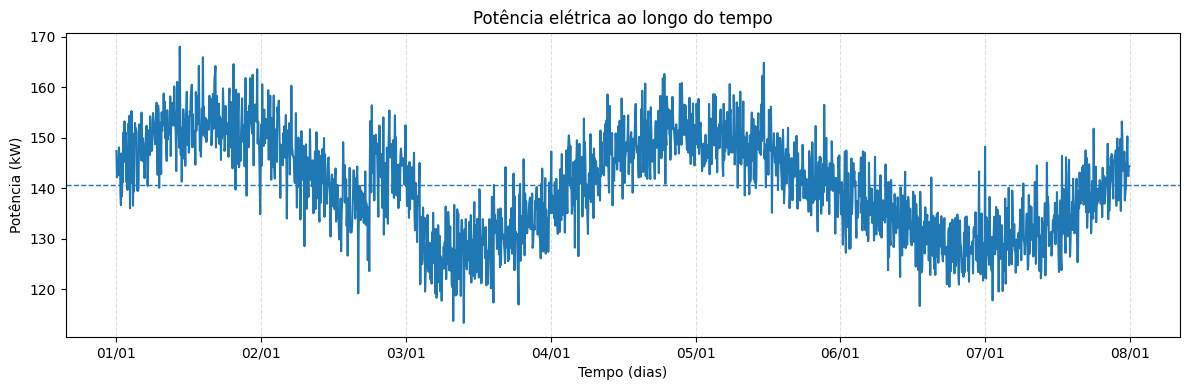

In [9]:
plt.figure(figsize=(12,4))
plt.plot(df_cop.index, df_cop["potencia_kw"])
plt.axhline(df_cop["potencia_kw"].mean(), linestyle="--", linewidth=1)

plt.title("Potência elétrica ao longo do tempo")
plt.ylabel("Potência (kW)")
plt.xlabel("Tempo (dias)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))
ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()


Do dia 02/01 para o dia 03/01, houve aumento de potência simultâneo à queda do COP, indicando piora de eficiência. A tendência sugere que o sistema entrou em condição operacional desfavorável (maior esforço do compressor sem entrega equivalente), possivelmente por degradação na rejeição de calor/condensação, controle instável ou alteração de regime (entrada de equipamento/estágio). Os próximos passos são correlacionar com vazão e com $\Delta T$ entre entrada e saída para confirmar se houve perda de capacidade térmica ou apenas aumento de consumo.

### 6.4) $\Delta T$ da água ao longo do tempo

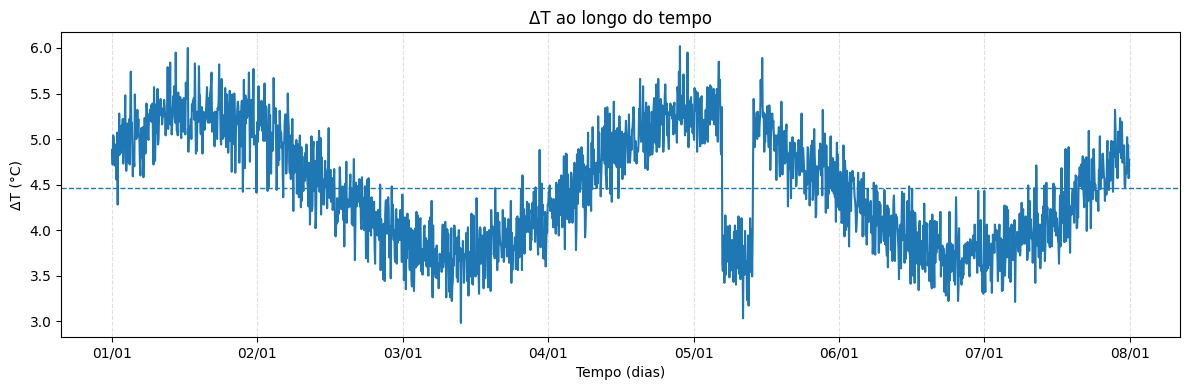

In [10]:
plt.figure(figsize=(12,4))
plt.plot(df_cop.index, df_cop["dT_C"])
plt.axhline(df_cop["dT_C"].mean(), linestyle="--", linewidth=1)

plt.title("ΔT ao longo do tempo")
plt.ylabel("ΔT (°C)")
plt.xlabel("Tempo (dias)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))

ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

No início do dia 05 observa-se uma queda abrupta do $\Delta T$, acompanhada de redução do COP, sem variação significativa da potência elétrica. Isso indica perda momentânea de capacidade térmica do sistema, provavelmente associada a redução de vazão ou alteração hidráulica/operacional, e não a aumento de consumo energético. Trata-se de um evento pontual, característico de causa especial, distinto do observado no período 02–03.

### 6.5) Vazão ao longo do tempo

In [11]:
plt.figure(figsize=(12,4))
plt.plot(df_cop.index, df_cop["vazao_m3_s"])
plt.axhline(df_cop["vazao_m3_s"].mean(), linestyle="--", linewidth=1)

plt.title("Vazão de água ao longo do tempo")
plt.ylabel("Vazão (m³/h)")
plt.xlabel("Tempo (dias)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))

plt.tight_layout()
plt.show()

KeyError: 'vazao_m3_s'

<Figure size 1200x400 with 0 Axes>

Nota-se que, no dia:

- 02→03: queda abrupta e sustentada de vazão indica evento operacional/hidráulico (bomba/valvulagem). Este evento explica a queda do COP por redução de capacidade térmica.

- Dia 05: ausência de queda relevante de vazão sugere que a queda de COP e de $\Delta T$ decorre de perda de efetividade térmica, e não de restrição de fluxo.

- Fim do dia 06: redução moderada e instabilidade na vazão apontam para ajuste/oscilações no controle hidráulico, coerente com a baixa degradação pontual do COP.

### 6.6) Histograma do COP

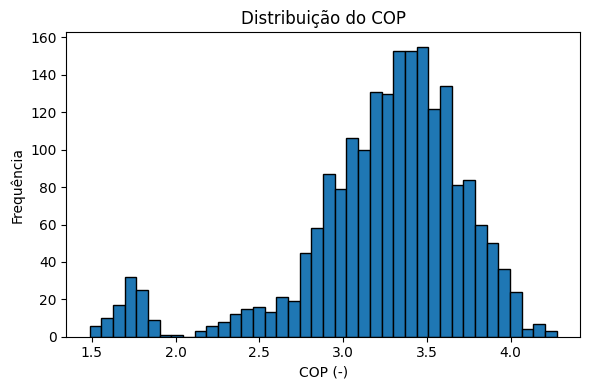

In [ ]:
plt.figure(figsize=(6,4))
plt.hist(df_cop["COP"], bins=40, edgecolor='black')
plt.title("Distribuição do COP")
plt.xlabel("COP (-)")
plt.ylabel("Frequência")
plt.tight_layout()
plt.show()

Lembrando que:

In [ ]:
cop_stats

count    2016.000000
mean        3.243186
std         0.500108
min         1.486778
10%         2.708801
25%         3.032839
50%         3.326981
75%         3.564948
90%         3.772873
max         4.274710
Name: COP, dtype: float64

A análise estatística do COP mostra média de 3,24 e mediana de 3,33, com 50% dos valores concentrados entre 3,03 e 3,56, caracterizando um regime operacional estável e eficiente. Os valores mínimos observados ( $\approx $ 1,5) representam eventos raros e pontuais, coerentes com causas especiais previamente identificadas na análise temporal, como quedas abruptas de vazão e alterações momentâneas de controle. A presença de valores máximos acima de 4 indica potencial de operação mais eficiente sob condições favoráveis.

### 6.7) Relações entre COP e variáveis operacionais
#### 6.7.1) COP vs Potência

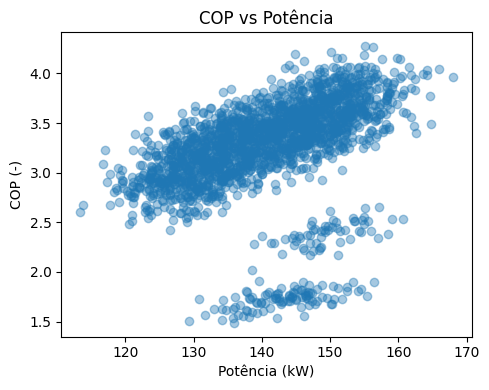

In [ ]:
plt.figure(figsize=(5,4))
plt.scatter(df_cop["potencia_kw"], df_cop["COP"], alpha=0.4)
plt.xlabel("Potência (kW)")
plt.ylabel("COP (-)")
plt.title("COP vs Potência")
plt.tight_layout()
plt.show()

A relação entre COP e potência elétrica evidencia a presença de clusters operacionais bem definidos. Observa-se um cluster dominante com correlação positiva entre potência e COP, indicando que o sistema opera de forma mais eficiente quando próximo do seu ponto de projeto. Em paralelo, identificam-se clusters distintos de baixa eficiência, nos quais a potência elétrica permanece elevada enquanto o COP se reduz significativamente. Esses clusters caracterizam regimes operacionais anômalos, associados à perda de capacidade térmica do sistema, e corroboram as análises temporais, estatísticas e hidráulicas previamente realizadas.

#### 6.7.2) COP vs Vazão

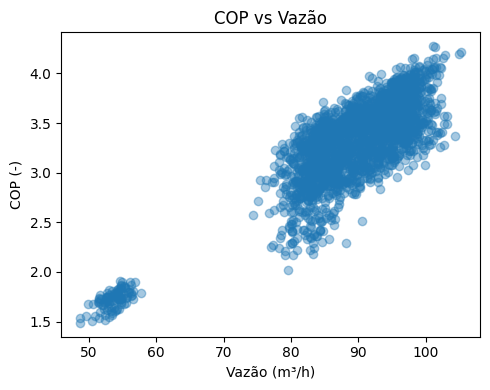

In [ ]:
plt.figure(figsize=(5,4))
plt.scatter(df_cop["vazao_m3_s"], df_cop["COP"], alpha=0.4)
plt.xlabel("Vazão (m³/h)")
plt.ylabel("COP (-)")
plt.title("COP vs Vazão")
plt.tight_layout()
plt.show()


A análise de COP em função da vazão revela a presença de clusters operacionais bem definidos. O cluster dominante corresponde ao regime normal de operação, com vazões elevadas e COP alto. Um segundo cluster, claramente separado, caracteriza eventos de vazão reduzida associados a COP significativamente menor, evidenciando um regime anômalo de operação. A separação entre clusters indica que as perdas de eficiência observadas estão fortemente correlacionadas a alterações hidráulicas, e não a variações contínuas do processo.

#### 6.7.3) COP vs $\Delta T$

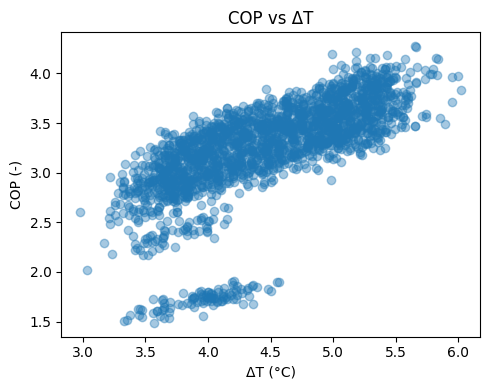

In [ ]:
plt.figure(figsize=(5,4))
plt.scatter(df_cop["dT_C"], df_cop["COP"], alpha=0.4)
plt.xlabel("ΔT (°C)")
plt.ylabel("COP (-)")
plt.title("COP vs ΔT")
plt.tight_layout()
plt.show()

A análise da relação entre COP e $\Delta T$ evidencia a presença de clusters operacionais bem definidos. O cluster principal, associado a maiores valores de $\Delta T$, representa o regime normal de operação, com elevada eficiência térmica. Observam-se ainda dois clusters inferiores na faixa de $\Delta T$ entre 3,5 e 4,5 °C, correspondentes a regimes de eficiência degradada e anômala. Esses clusters refletem perdas progressivas de capacidade térmica, coerentes com eventos hidráulicos e operacionais previamente identificados, reforçando que as quedas de COP observadas não são aleatórias, mas associadas a condições específicas de operação.

### 6.8) Pressão do óleo do Chiller

#### 6.8.1) Ao longo do tempo

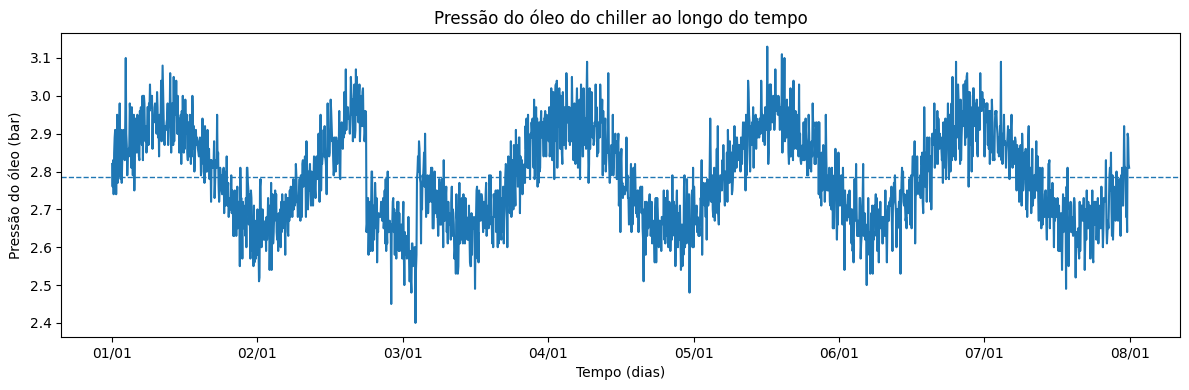

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(df_cop.index, df_cop["pressao_oleo_bar"])
plt.axhline(df_cop["pressao_oleo_bar"].mean(), linestyle="--", linewidth=1)

plt.title("Pressão do óleo do chiller ao longo do tempo")
plt.ylabel("Pressão do óleo (bar)")
plt.xlabel("Tempo (dias)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))

plt.tight_layout()
plt.show()

A pressão do óleo do chiller manteve-se estável ao longo do período analisado, com variações cíclicas normais e apenas uma resposta transitória durante o evento do dia 02 para 03. Não há indícios de que o sistema de lubrificação tenha sido a causa das quedas de COP observadas. 

#### 6.8.2) COP vs Pressão do óleo

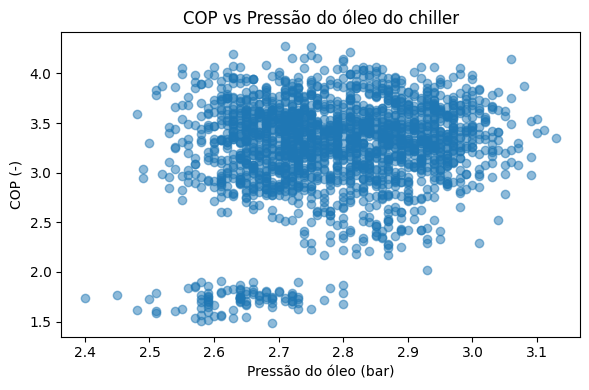

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df_cop["pressao_oleo_bar"], df_cop["COP"], alpha=0.5)

plt.title("COP vs Pressão do óleo do chiller")
plt.xlabel("Pressão do óleo (bar)")
plt.ylabel("COP (-)")

plt.tight_layout()
plt.show()

A análise de COP em função da pressão do óleo do chiller evidencia um cluster dominante de operação normal, concentrado em pressões de aproximadamente 2,6 a 3,0 bar, no qual o COP varia amplamente entre cerca de 2,8 e 4,1, sem correlação significativa entre as variáveis. Esse comportamento indica que, dentro da faixa normal de operação do sistema de lubrificação, a pressão do óleo não é um fator determinante da eficiência do sistema. Observa-se, entretanto, um pequeno cluster de COP reduzido, com valores entre aproximadamente 1,5 e 1,9, associado a pressões de óleo ligeiramente menores, em torno de 2,6–2,7 bar. Esse agrupamento é interpretado como uma resposta secundária do sistema de lubrificação a eventos operacionais anômalos previamente identificados, e não como a causa primária da degradação do desempenho térmico do sistema.

### 6.9) Nível do tanque de água

#### 6.9.1) Ao longo do tempo

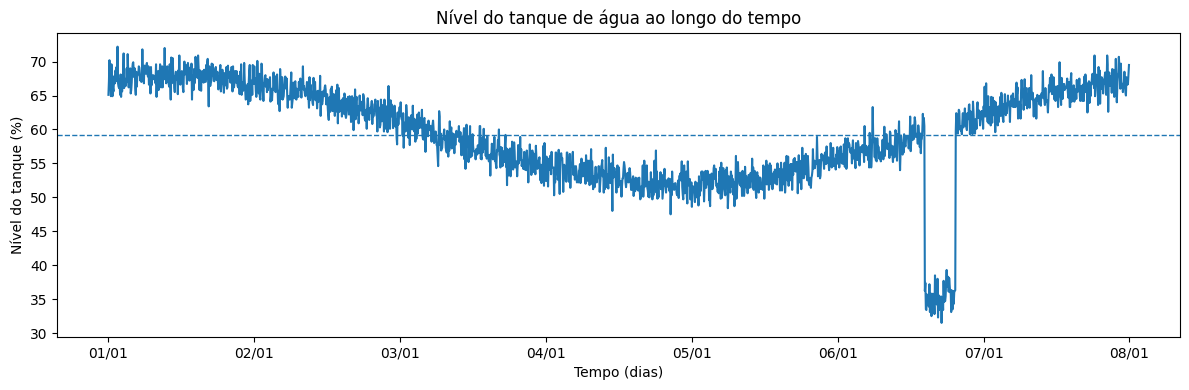

In [ ]:
plt.figure(figsize=(12,4))
plt.plot(df_cop.index, df_cop["nivel_tanque_pct"])
plt.axhline(df_cop["nivel_tanque_pct"].mean(), linestyle="--", linewidth=1)

plt.title("Nível do tanque de água ao longo do tempo")
plt.ylabel("Nível do tanque (%)")
plt.xlabel("Tempo (dias)")

ax = plt.gca()
ax.xaxis.set_major_locator(mdates.DayLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter("%d/%m"))

plt.tight_layout()
plt.show()

A análise do nível do tanque de água mostra operação majoritária em faixa nominal entre aproximadamente 58% e 65%. Entretanto, no fim do dia 06 observa-se uma queda abrupta do nível para valores próximos de 30–35%, caracterizando uma condição operacional crítica. Esse evento está associado à redução da estabilidade hidráulica do sistema, com potencial ocorrência de cavitação e queda de vazão, explicando a degradação pontual do COP observada nesse período. Trata-se de um evento de causa especial, distinto da oscilação normal do sistema.

#### 6.9.2) COP vs Nível do tanque de água

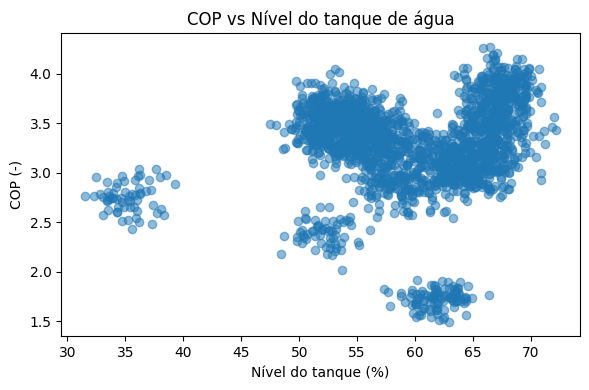

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(df_cop["nivel_tanque_pct"], df_cop["COP"], alpha=0.5)

plt.title("COP vs Nível do tanque de água")
plt.xlabel("Nível do tanque (%)")
plt.ylabel("COP (-)")

plt.tight_layout()
plt.show()


A análise de COP em função do nível do tanque de água evidencia múltiplos clusters operacionais. O cluster dominante, associado a níveis entre aproximadamente 55% e 70%, representa o regime normal de operação com COP elevado. Observa-se um cluster de nível baixo (≈33–38%) com COP moderado, indicando que reduções pontuais do nível nem sempre implicam degradação severa da eficiência. Por outro lado, identificam-se clusters anômalos com COP inferior a 2,0 mesmo em níveis nominais do tanque (≈60–65%), evidenciando que perdas significativas de eficiência estão associadas a condições hidráulicas e operacionais específicas, e não exclusivamente ao nível do reservatório.

## Observação:
Em um ambiente industrial, análises equivalentes podem ser operacionalizadas em ferramentas como Minitab (SPC, gráficos de controle, estudos de estabilidade e detecção de causas especiais) e TrendMiner (análise de séries temporais, comparação de janelas operacionais, detecção de eventos e correlação entre tags), especialmente quando integradas ao historiador da planta.

## 7) Conclusão

A análise integrada dos dados históricos do sistema de refrigeração — incluindo séries temporais, estatística descritiva, histogramas e análises multivariadas entre o COP e as principais variáveis operacionais — indica que o sistema opera majoritariamente de forma estável e eficiente, apresentando eventos pontuais de degradação de desempenho associados a regimes operacionais específicos, e não a falhas estruturais.

Foram identificados clusters bem definidos de baixa eficiência, distintos do regime dominante. Destaca-se um cluster anômalo severo, com COP entre 1,5 e 1,9, associado a quedas abruptas de vazão, e um cluster de eficiência degradada, com COP entre 2,2 e 2,6, relacionado a regimes transitórios, redução de $\Delta T$ e instabilidades hidráulicas. Esses eventos configuram causas especiais, ocorrendo de forma pontual (≈10% do tempo).

A análise cruzada das variáveis operacionais permitiu explicar fisicamente a formação desses clusters e identificar os principais fatores associados às perdas de eficiência. Observou-se que:

- a potência elétrica não é o fator determinante isolado da eficiência;
- a vazão é o principal fator associado ao desempenho do COP;
- a redução do $\Delta T$ está diretamente relacionada à perda de eficiência térmica;
- a pressão do óleo apresenta comportamento estável, atuando como resposta secundária aos eventos;
- o nível do tanque influencia a estabilidade hidráulica, sendo condição necessária, mas não suficiente, para garantir alto COP.

Do ponto de vista hidráulico e temporal, observou-se no fim do dia 06 uma queda abrupta do nível do tanque para cerca de 30–35%, condição crítica que favorece instabilidade da vazão e explica a degradação pontual do COP nesse período. Já o evento entre os dias 02 e 03 está fortemente associado à redução efetiva da vazão, enquanto no dia 05 a queda moderada do COP foi relacionada à redução do $\Delta T$, sem alterações relevantes nas demais variáveis.

De forma consolidada, conclui-se que o sistema é tecnicamente saudável, com potencial de melhoria concentrado em otimização operacional, especialmente no controle da vazão, definição de limites mínimos para o nível do tanque e revisão das lógicas de controle em regimes transitórios, resultando em ganhos de eficiência energética e confiabilidade do processo.

---

Adicionalmente, análises mais avançadas poderiam ser aplicadas ao conjunto de dados, como modelos de regressão linear para quantificar relações entre variáveis operacionais, bem como técnicas de clusterização para identificar diferentes regimes de operação do sistema.

No entanto, para o objetivo deste desafio — obter respostas rápidas e acionáveis sobre o comportamento do sistema e possíveis desvios de desempenho — a abordagem adotada mostrou-se adequada. As análises exploratórias realizadas permitem identificar padrões, tendências e eventos relevantes sem a necessidade de modelos mais complexos ou de um refinamento excessivo dos dados, o que é compatível com cenários industriais em que decisões precisam ser tomadas de forma ágil.

Em contextos de aprofundamento analítico ou de otimização contínua, o uso dessas técnicas avançadas poderia agregar valor adicional, especialmente quando combinado com um histórico de dados mais extenso e com medições complementares do sistema.